# Zadanie 2 Klasyfikacja tabelaryczna: League of Legends (15 min)

**Cel:** przewidzieć zwycięzcę meczu (`blueWin`: 1 = wygrywa niebieski, 0 = czerwony) na podstawie statystyk z pierwszych 15 minut gry.

**Zbiór:** `match_data_v5.csv` — 24 225 meczów SoloQ (EUNE/EUW), 28 cech numerycznych, target zbalansowany ~50/50, brak braków.



## 1. Importy i konfiguracja

In [1]:
from Wspolne import ustaw_seed, wykres_krzywych_uczenia, macierz_pomylek, raport_klasyfikacji, tabela_porownawcza
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

ustaw_seed(42)

## 2. Wczytanie i poznanie danych

In [2]:
df = pd.read_csv('match_data_v5.csv')
df = df.drop(columns=['matchId']) 
print("Wymiar:", df.shape)
print("Braki danych:", df.isna().sum().sum())
df.head()

Wymiar: (24225, 28)
Braki danych: 0


,blueTeamControlWardsPlaced,blueTeamWardsPlaced,blueTeamTotalKills,blueTeamDragonKills,blueTeamHeraldKills,blueTeamTowersDestroyed,blueTeamInhibitorsDestroyed,blueTeamTurretPlatesDestroyed,blueTeamFirstBlood,blueTeamMinionsKilled,...,redTeamHeraldKills,redTeamTowersDestroyed,redTeamInhibitorsDestroyed,redTeamTurretPlatesDestroyed,redTeamMinionsKilled,redTeamJungleMinions,redTeamTotalGold,redTeamXp,redTeamTotalDamageToChamps,blueWin
0,2,23,4,2,0,0,0,7,0,388,...,0,2,0,1,400,94,29637,32613,27239,1
1,2,46,12,1,0,1,0,10,0,348,...,0,1,0,4,373,76,28970,30320,36585,0
2,2,19,13,0,0,0,0,11,0,331,...,0,2,0,3,340,84,30510,29464,42984,0
3,3,28,8,0,1,1,0,9,1,355,...,0,0,0,5,378,87,25157,31069,28229,0
4,3,30,11,1,1,1,0,7,0,370,...,0,1,0,5,382,96,26052,29475,19245,1


{0: 0.505, 1: 0.495}


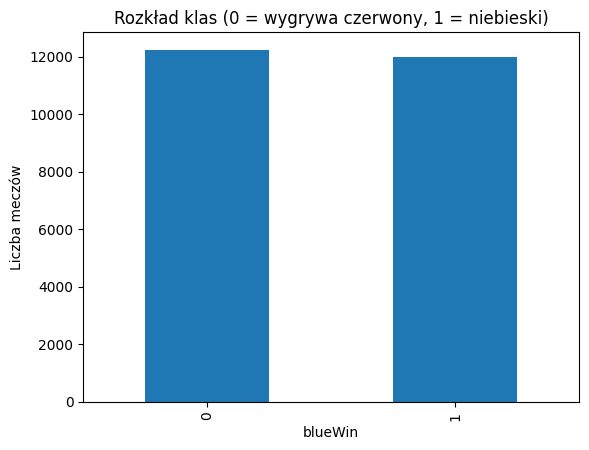

In [3]:
print(df['blueWin'].value_counts(normalize=True).round(3).to_dict())
df['blueWin'].value_counts().plot(kind='bar')
plt.title('Rozkład klas (0 = wygrywa czerwony, 1 = niebieski)')
plt.xlabel('blueWin')
plt.ylabel('Liczba meczów')
plt.show()

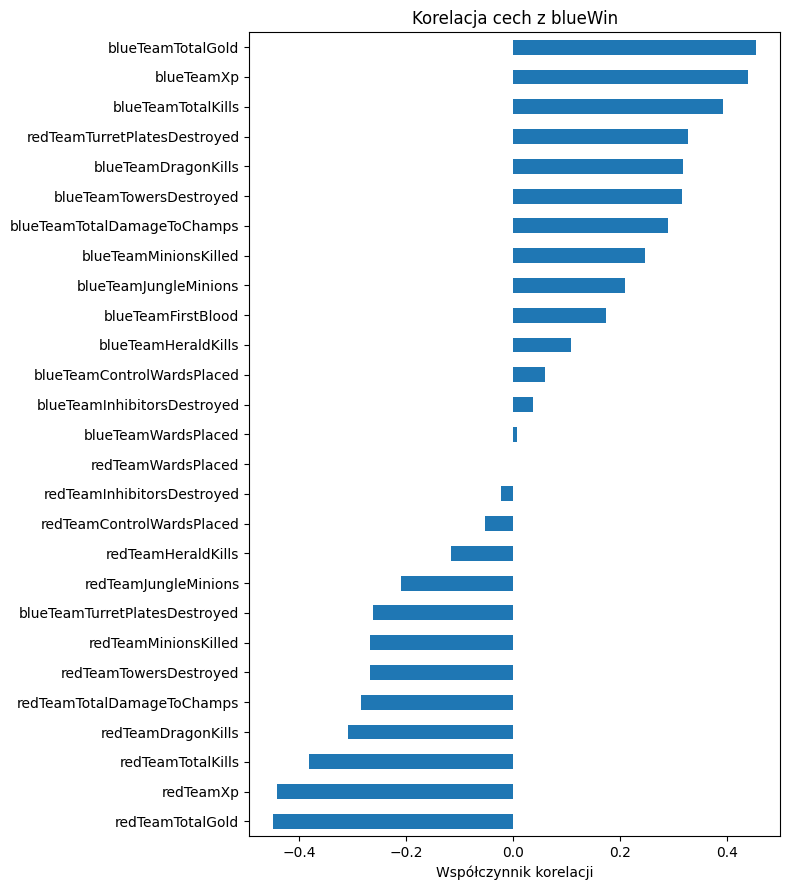

In [4]:
korelacje = df.corr()['blueWin'].drop('blueWin').sort_values()
plt.figure(figsize=(8, 9))
korelacje.plot(kind='barh')
plt.title('Korelacja cech z blueWin')
plt.xlabel('Współczynnik korelacji')
plt.tight_layout()
plt.show()

## 3. Przygotowanie danych

Wszystkie cechy są numeryczne, więc wystarczy skalowanie (`StandardScaler`).
Podział 60/20/20 ze stratyfikacją (zachowanie proporcji klas).

In [5]:
X = df.drop(columns=['blueWin']).values
y = df['blueWin'].values
nazwy_cech = df.drop(columns=['blueWin']).columns

X_train, X_reszta, y_train, y_reszta = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_reszta, y_reszta, test_size=0.5, random_state=42, stratify=y_reszta)

skaler = StandardScaler()
X_train = skaler.fit_transform(X_train)
X_val = skaler.transform(X_val)
X_test = skaler.transform(X_test)

LICZBA_CECH = X_train.shape[1]
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (14535, 27) Val: (4845, 27) Test: (4845, 27)


## 4. Funkcje pomocnicze

In [6]:
def buduj_mlp(warstwy=(64, 32), dropout=0.0, batchnorm=False, l2=0.0):
    reg = tf.keras.regularizers.L2(l2) if l2 > 0 else None
    model = Sequential()
    model.add(layers.Input((LICZBA_CECH,)))
    for n in warstwy:
        model.add(layers.Dense(n, kernel_regularizer=reg))
        if batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid')) 
    return model


def trenuj(model, epochs=50, batch_size=128):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    return model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=epochs, batch_size=batch_size, callbacks=[stop], verbose=0)


def oblicz_metryki(model):
    prob = model.predict(X_test, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'AUC': roc_auc_score(y_test, prob),
    }


wyniki = {} 

## Sanity check (kontrola poprawności)
Szybka kontrola wg przepisu Karpathy'ego (wykład 11): strata początkowa powinna odpowiadać modelowi bez wiedzy, a sieć musi umieć przeuczyć małą partię danych.

In [ ]:
# Sanity check (przepis Karpathy'ego, wykład 11): strata początkowa ~ -log(1/2) i przeuczenie małej partii
import math
oczekiwana = math.log(2)
test = buduj_mlp(warstwy=(32,))
test.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
strata = test.evaluate(X_train[:256], y_train[:256], verbose=0)[0]
print(f"Strata początkowa: {strata:.3f} | oczekiwana -log(1/2) = {oczekiwana:.3f}")
test.fit(X_train[:100], y_train[:100], epochs=50, verbose=0)
acc = test.evaluate(X_train[:100], y_train[:100], verbose=0)[1]
print(f"Dokładność na 100 przykładach po przeuczeniu: {acc:.3f} (powinno być ~1.0)")

## 5. Model bazowy — regresja logistyczna

In [7]:
model_log = LogisticRegression(max_iter=1000).fit(X_train, y_train)
prob_log = model_log.predict_proba(X_test)[:, 1]
pred_log = (prob_log >= 0.5).astype(int)
wyniki['Regresja log.'] = {
    'accuracy': accuracy_score(y_test, pred_log),
    'precision': precision_score(y_test, pred_log),
    'recall': recall_score(y_test, pred_log),
    'F1': f1_score(y_test, pred_log),
    'AUC': roc_auc_score(y_test, prob_log),
}
print(wyniki['Regresja log.'])

{'accuracy': 0.7593395252837978, 'precision': 0.7655440414507773, 'recall': 0.739983305509182, 'F1': 0.7525466893039049, 'AUC': 0.8425538753509831}


## 6. Model: prosty MLP

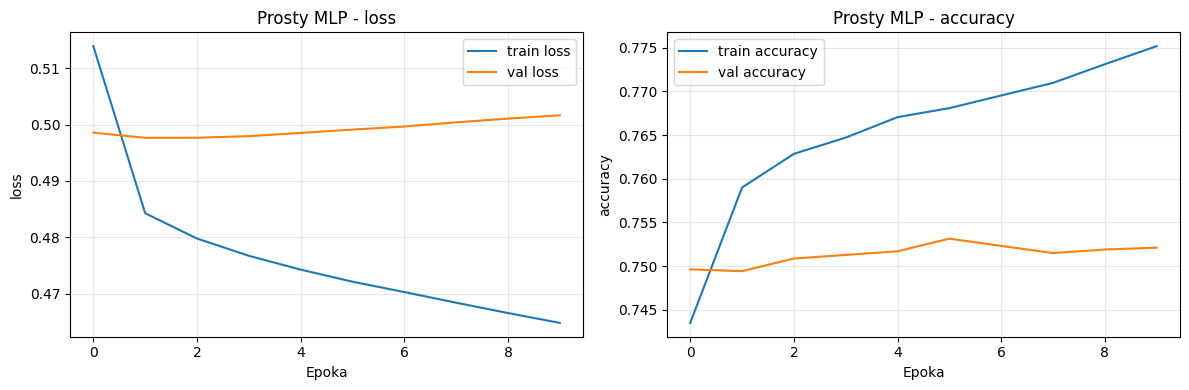

{'accuracy': 0.7531475748194014, 'precision': 0.7754820936639119, 'recall': 0.7049248747913188, 'F1': 0.7385220813292523, 'AUC': 0.838018021733514}


In [8]:
model_mlp = buduj_mlp(warstwy=(64, 32))
historia = trenuj(model_mlp)
wykres_krzywych_uczenia(historia, metryki=('loss', 'accuracy'), tytul='Prosty MLP')
wyniki['MLP'] = oblicz_metryki(model_mlp)
print(wyniki['MLP'])

## 7. Model: MLP z BatchNorm

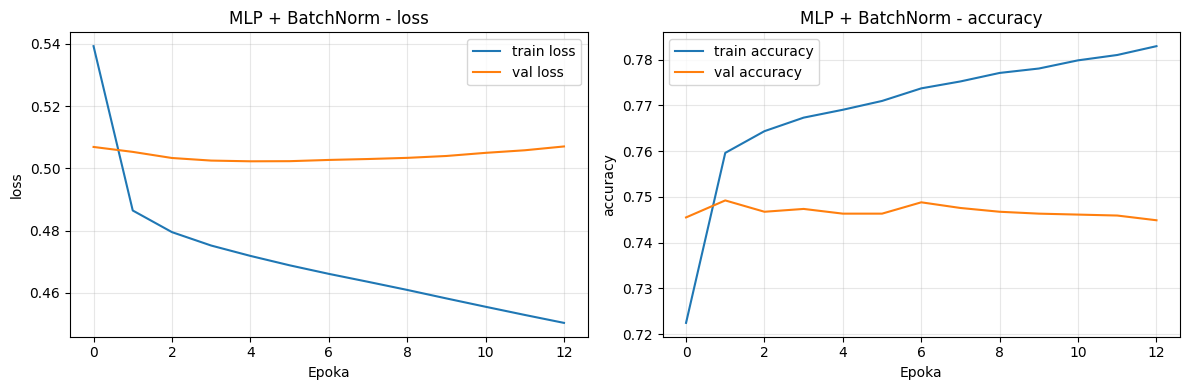

{'accuracy': 0.7552115583075335, 'precision': 0.7691281138790036, 'recall': 0.7216193656093489, 'F1': 0.7446167097329888, 'AUC': 0.8367634638103113}


In [9]:
model_bn = buduj_mlp(warstwy=(64, 32), batchnorm=True)
historia = trenuj(model_bn)
wykres_krzywych_uczenia(historia, metryki=('loss', 'accuracy'), tytul='MLP + BatchNorm')
wyniki['MLP+BatchNorm'] = oblicz_metryki(model_bn)
print(wyniki['MLP+BatchNorm'])

## 8. Model: MLP z regularyzacją L2

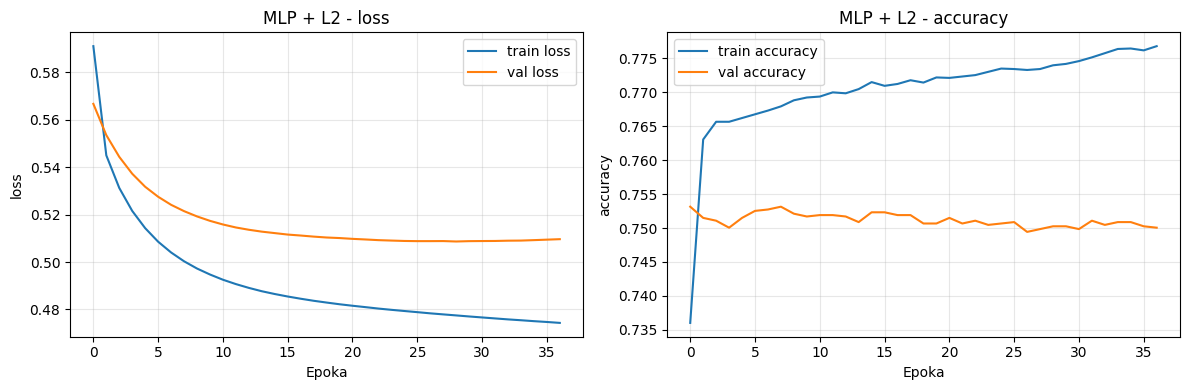

{'accuracy': 0.750670794633643, 'precision': 0.7687782805429865, 'recall': 0.7090984974958264, 'F1': 0.737733391228832, 'AUC': 0.8362576527777683}


In [10]:
model_l2 = buduj_mlp(warstwy=(64, 32), l2=0.001)
historia = trenuj(model_l2)
wykres_krzywych_uczenia(historia, metryki=('loss', 'accuracy'), tytul='MLP + L2')
wyniki['MLP+L2'] = oblicz_metryki(model_l2)
print(wyniki['MLP+L2'])

## 9. Walidacja krzyżowa (K-fold)

In [11]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_foldy = []
for nr, (idx_tr, idx_va) in enumerate(kf.split(X, y), start=1):
    s = StandardScaler()
    X_tr = s.fit_transform(X[idx_tr])
    X_va = s.transform(X[idx_va])
    model_cv = buduj_mlp(warstwy=(64, 32), batchnorm=True)
    model_cv.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model_cv.fit(X_tr, y[idx_tr], validation_data=(X_va, y[idx_va]),
                 epochs=30, batch_size=128, callbacks=[stop], verbose=0)
    acc = model_cv.evaluate(X_va, y[idx_va], verbose=0)[1]
    acc_foldy.append(acc)
    print(f"Fold {nr}: accuracy = {acc:.4f}")
print(f"\nŚrednia accuracy: {np.mean(acc_foldy):.4f} +/- {np.std(acc_foldy):.4f}")

Fold 1: accuracy = 0.7610
Fold 2: accuracy = 0.7558
Fold 3: accuracy = 0.7550
Fold 4: accuracy = 0.7540
Fold 5: accuracy = 0.7550

Średnia accuracy: 0.7562 +/- 0.0025


## 10. Ocena najlepszego modelu

Najlepszy model (sieć): MLP


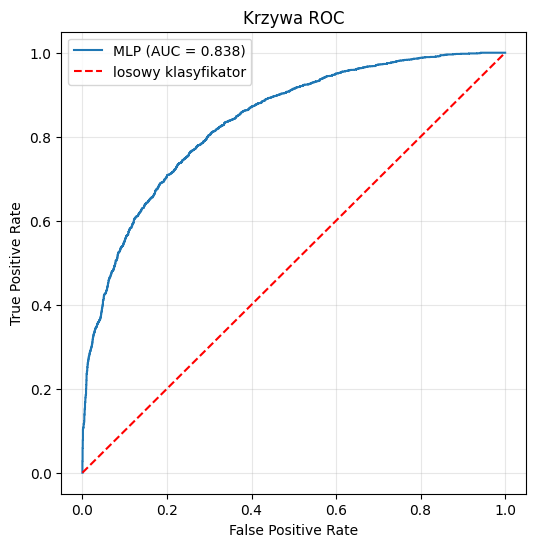

In [12]:
modele = {'MLP': model_mlp, 'MLP+BatchNorm': model_bn, 'MLP+L2': model_l2}
najlepszy_nazwa = max(modele, key=lambda k: wyniki[k]['AUC'])
najlepszy = modele[najlepszy_nazwa]
print("Najlepszy model (sieć):", najlepszy_nazwa)

prob = najlepszy.predict(X_test, verbose=0).ravel()
pred = (prob >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_test, prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'{najlepszy_nazwa} (AUC = {roc_auc_score(y_test, prob):.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='losowy klasyfikator')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

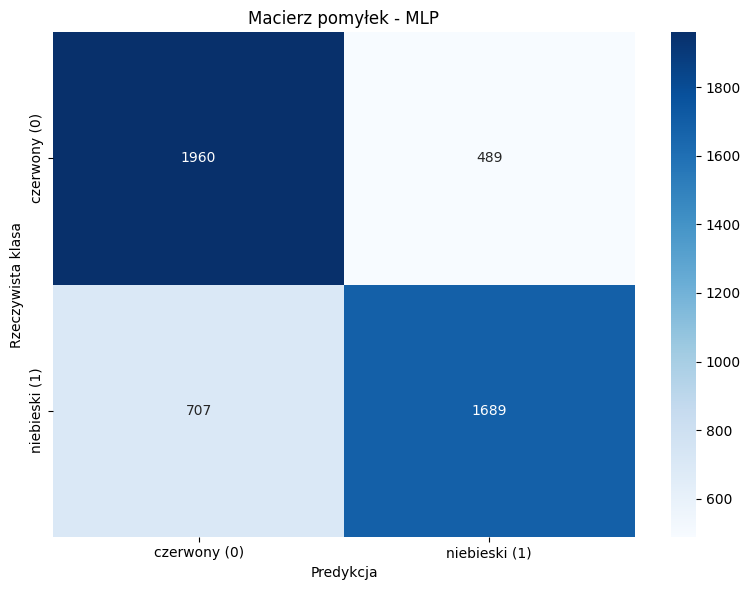

              precision    recall  f1-score   support

    czerwony       0.73      0.80      0.77      2449
   niebieski       0.78      0.70      0.74      2396

    accuracy                           0.75      4845
   macro avg       0.76      0.75      0.75      4845
weighted avg       0.75      0.75      0.75      4845



In [13]:
macierz_pomylek(y_test, pred, etykiety=['czerwony (0)', 'niebieski (1)'], tytul=f'Macierz pomyłek - {najlepszy_nazwa}')
print(raport_klasyfikacji(y_test, pred, etykiety=['czerwony', 'niebieski']))

## 11. Porównanie i wnioski

In [14]:
tabela = tabela_porownawcza(wyniki)
tabela.sort_values('AUC', ascending=False)

,accuracy,precision,recall,F1,AUC
Regresja log.,0.759340,0.765544,0.739983,0.752547,0.842554
MLP,0.753148,0.775482,0.704925,0.738522,0.838018
MLP+BatchNorm,0.755212,0.769128,0.721619,0.744617,0.836763
MLP+L2,0.750671,0.768778,0.709098,0.737733,0.836258


**Wnioski:**
- **Najlepsza okazała się regresja logistyczna** (accuracy 0.759, AUC 0.843) żaden MLP jej nie pobił (wszystkie w granicach ~1 pp). Problem jest niemal **liniowo separowalny**: przewaga w złocie/doświadczeniu/zabójstwach liniowo wskazuje zwycięzcę, więc sieć neuronowa nie ma czego "dokładać". To ciekawy kontrast wobec zadań 1 i 3, gdzie nieliniowość dawała sieciom wyraźną przewagę.
- **BatchNorm i L2 praktycznie nie zmieniły wyniku** (różnice rzędu 0.5–1 pp accuracy) przy tak prostej, liniowej zależności regularyzacja nie ma dużego pola do poprawy.
- **K-fold potwierdził stabilność:** accuracy 0.756 ± 0.003 (znikome odchylenie między foldami).
- **Najważniejsze cechy** (z wykresu korelacji): różnice w łącznym złocie i doświadczeniu drużyn oraz liczba zabójstw/zniszczonych wież typowe wskaźniki przewagi po 15 minutach.
- **Sufit dokładności ~75%** jest naturalny: po 15 minutach mecz często nie jest jeszcze rozstrzygnięty, więc części gier nie da się przewidzieć z niepełnych danych.
- **Wyzwania:** silnie skorelowane cechy (gold/xp/kills), przewidywanie wyniku z niepełnej rozgrywki.